In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
s0 = 0.0016 # slope
n = 0.02 # manning's roughness factor
B = 20 # bottom width

def calc_Fr(y,Q):
    B = 20 # bottom width
    T = 4*y+B # top width
    A = (T+B)*y/2 # cross-sectional area
    Fr = T*Q**2/(32.2*A**3)
    return Fr

def calc_R(y):
    B = 20 # bottom width
    T = 4*y+B # top width
    A = (T+B)*y/2 # cross-sectional area
    P = B+T+np.sqrt((2*y)**2+y**2)
    R = A/P # hydraulic radius 
    return R,A    

y_start = 5 # unit: ft
alpha = 1.10 # velocity head correction factor
y_end = 4.6 # unit: ft

In [3]:
# calculate yc
yc = np.nan
for y in np.arange(0.001,5,0.001):
    Fr = calc_Fr(y,400)
    if abs(Fr-1)<0.001:
        yc = y
yc

2.148

In [4]:
# calculate yn
yn = np.nan
for y in np.arange(0.001,5,0.001):
    R,A = calc_R(y)
    Q = 1.49/n*A*R**(2/3)*s0**(1/2)
    if abs(Q-400)<0.1:
        yn = y
yn

3.63

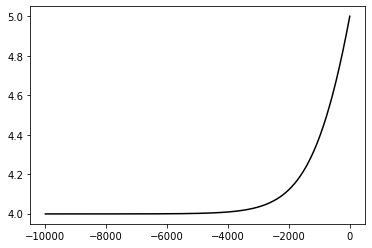

In [25]:
# Method #1, fix dx, solve for dy
dx = -1

def calc_dy(y,dx,Q):
    Fr = calc_Fr(y,Q)
    R,A = calc_R(y)
    V = Q/A
    sf = (n**2)*(V**2)/(2.22*R**(2/3))
    dy = dx*(s0-sf)/(1-alpha*Fr**2)
    return dy

y_list = [5]
x_list = [0]
i = 0
while True:
    dy = calc_dy(y_list[-1],dx,400)
    new_y = y_list[-1]+dy
    new_x = x_list[-1]+dx
    y_list.append(new_y)
    x_list.append(new_x)
    i += 1 
    if i>10000:
        break
plt.plot(x_list,y_list,'k-')

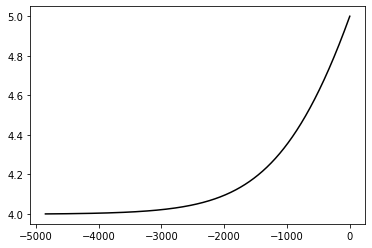

In [21]:
# Method #2: fix dy, solve for dx
dy = -0.001

def calc_dx(y,dy,Q,s0):
    y1 = y
    y2 = y+dy
    R1,A1 = calc_R(y1)
    V1 = Q/A1
    sf1 = (n**2)*(V1**2)/(2.22*R1**(2/3))
    E1 = y1+alpha*V1**2/(2*32.2)
    R2,A2 = calc_R(y2)
    V2 = Q/A2
    sf2 = (n**2)*(V2**2)/(2.22*R2**(2/3))
    E2 = y2+alpha*V2**2/(2*32.2)
    sf = (sf1+sf2)/2
    dx = (E2-E1)/(s0-sf)
    return dx

y_list = [5]
x_list = [0]
i = 0
while True:
    dx = calc_dx(y_list[-1],dy,400,s0)
    new_y = y_list[-1]+dy
    new_x = x_list[-1]+dx
    y_list.append(new_y)
    x_list.append(new_x)
    i += 1 
    if new_y<4:
        break
plt.plot(x_list,y_list,'k-')